# 03 — Classical ML Models Baseline

Experiment with classical ML models (Logistic Regression, SVM, Random Forest, etc.) on the preprocessed satellite imagery dataset.

**Evaluation metrics:**
- Accuracy
- Precision / Recall / F1 per class
- Confusion matrix
- Training time (wallclock time)

**Goal:** Establish a baseline to compare against CNN models later.

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path
import json
import time

from sklearn.linear_model import LogisticRegression
from sklearn.svm import SVC
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import StratifiedKFold
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score,
    confusion_matrix, classification_report
)

# Reproducibility
np.random.seed(42)

# Setup
PREP_DIR = Path("../data_preprocessed")
RESULTS_DIR = Path("../results")
RESULTS_DIR.mkdir(exist_ok=True)
CLASSES = ["cloudy", "desert", "green_area", "water"]

# Load preprocessed data
print("Loading preprocessed dataset...")
X_train = np.load(PREP_DIR / "X_train.npy")
X_test = np.load(PREP_DIR / "X_test.npy")
y_train = np.load(PREP_DIR / "y_train.npy")
y_test = np.load(PREP_DIR / "y_test.npy")

# Load class mapping
with open(PREP_DIR / "class_mapping.json") as f:
    mapping = json.load(f)
    idx_to_class = {int(k): v for k, v in mapping["idx_to_class"].items()}

print(f"✓ Data loaded")
print(f"  Train: {X_train.shape}, Test: {X_test.shape}")
print(f"  Classes: {list(idx_to_class.values())}")

Loading preprocessed dataset...
✓ Data loaded
  Train: (4800, 64, 64, 3), Test: (1200, 64, 64, 3)
  Classes: ['cloudy', 'desert', 'green_area', 'water']


## 1. Prepare Data for Classical ML

In [3]:
# Flatten images into feature vectors (64x64x3 -> 12288)
X_train_flat = X_train.reshape(X_train.shape[0], -1)
X_test_flat = X_test.reshape(X_test.shape[0], -1)

print(f"Original shape: {X_train.shape}")
print(f"Flattened shape: {X_train_flat.shape}")
print()

# Standardize features (important for distance-based models like SVM, LogReg)
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train_flat)
X_test_scaled = scaler.transform(X_test_flat)

print(f"Train data: mean={X_train_scaled.mean():.4f}, std={X_train_scaled.std():.4f}")
print(f"Test data:  mean={X_test_scaled.mean():.4f}, std={X_test_scaled.std():.4f}")

Original shape: (4800, 64, 64, 3)
Flattened shape: (4800, 12288)

Train data: mean=0.0000, std=1.0000
Test data:  mean=-0.0072, std=0.9943


## 2. Quick Single Split Analysis - Individual Models

Before running 5-fold CV, let's do a quick analysis with a single train/validation split to understand each model's behavior and performance.

In [4]:
from sklearn.model_selection import train_test_split

# Create a single train/validation split for quick analysis
X_train_split, X_val_split, y_train_split, y_val_split = train_test_split(
    X_train_flat, y_train, test_size=0.2, random_state=42, stratify=y_train
)

# Scale the data
scaler_split = StandardScaler()
X_train_split_scaled = scaler_split.fit_transform(X_train_split)
X_val_split_scaled = scaler_split.transform(X_val_split)

print(f"Single Split Setup:")
print(f"  Training set: {X_train_split_scaled.shape}")
print(f"  Validation set: {X_val_split_scaled.shape}")
print(f"  Features: {X_train_split_scaled.shape[1]}")
print()

Single Split Setup:
  Training set: (3840, 12288)
  Validation set: (960, 12288)
  Features: 12288



### 2.1 Logistic Regression - Single Split Analysis

**Why analyze separately?**
- Logistic Regression is a linear model that finds optimal weights via iterative optimization
- It's sensitive to feature scaling and convergence settings
- Warning about `max_iter` suggests the optimizer didn't fully converge

**Expected issues:**
- May need higher `max_iter` for convergence with 12,288 features
- Requires proper feature scaling (which we handle with StandardScaler)

In [7]:
print("="*80)
print("LOGISTIC REGRESSION ANALYSIS")
print("="*80)

# Test with different max_iter values
for max_iter in [1000, 5000]:
    print(f"\nTesting with max_iter={max_iter}:")
    
    lr = LogisticRegression(max_iter=max_iter, solver='lbfgs', random_state=42, n_jobs=-1)
    
    start_time = time.time()
    lr.fit(X_train_split_scaled, y_train_split)
    train_time = time.time() - start_time
    
    y_val_pred = lr.predict(X_val_split_scaled)
    
    acc = accuracy_score(y_val_split, y_val_pred)
    prec = precision_score(y_val_split, y_val_pred, average='weighted', zero_division=0)
    rec = recall_score(y_val_split, y_val_pred, average='weighted', zero_division=0)
    f1 = f1_score(y_val_split, y_val_pred, average='weighted', zero_division=0)
    
    print(f"  Training time: {train_time:.2f}s")
    print(f"  Converged: {lr.n_iter_[0] < max_iter}")
    print(f"  Iterations needed: {lr.n_iter_[0]}")
    print(f"  Validation Accuracy: {acc:.4f}")
    print(f"  Validation Precision (weighted): {prec:.4f}")
    print(f"  Validation Recall (weighted): {rec:.4f}")
    print(f"  Validation F1 (weighted): {f1:.4f}")

print("\n" + "="*80)
print("KEY INSIGHTS - Logistic Regression:")
print("="*80)
print("• The convergence warning occurs because LBFGS optimizer needs many iterations")
print("• With 12,288 features (flattened 64×64×3 images), optimization takes longer")
print("• StandardScaler is CRITICAL: distances between iterations become small")
print("• Increasing max_iter helps, but trade-off: longer training time")
print("• Alternative: use 'saga' or 'sag' solvers which can be faster for large datasets")
print("="*80 + "\n")


LOGISTIC REGRESSION ANALYSIS

Testing with max_iter=1000:


/opt/anaconda3/envs/cv_env/lib/python3.10/site-packages/sklearn/linear_model/_logistic.py:465: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


  Training time: 75.60s
  Converged: False
  Iterations needed: 1000
  Validation Accuracy: 0.8052
  Validation Precision (weighted): 0.8154
  Validation Recall (weighted): 0.8052
  Validation F1 (weighted): 0.8028

Testing with max_iter=5000:
  Training time: 101.23s
  Converged: True
  Iterations needed: 1388
  Validation Accuracy: 0.7979
  Validation Precision (weighted): 0.8093
  Validation Recall (weighted): 0.7979
  Validation F1 (weighted): 0.7952

KEY INSIGHTS - Logistic Regression:
• The convergence warning occurs because LBFGS optimizer needs many iterations
• With 12,288 features (flattened 64×64×3 images), optimization takes longer
• StandardScaler is CRITICAL: distances between iterations become small
• Increasing max_iter helps, but trade-off: longer training time
• Alternative: use 'saga' or 'sag' solvers which can be faster for large datasets



### 2.2 Support Vector Machine (SVM) - Single Split Analysis

**Why SVM is different:**
- Uses kernel trick (RBF = Radial Basis Function) to find non-linear decision boundaries
- Training involves solving a quadratic programming problem (slower than LogReg)
- Less sensitive to feature scaling than LogReg but still benefits from it
- Complexity increases with dataset size: O(n²) to O(n³) depending on method

In [8]:
print("="*80)
print("SUPPORT VECTOR MACHINE (SVM) ANALYSIS")
print("="*80)

svm = SVC(kernel='rbf', gamma='scale', random_state=42)

start_time = time.time()
svm.fit(X_train_split_scaled, y_train_split)
train_time = time.time() - start_time

y_val_pred = svm.predict(X_val_split_scaled)

acc = accuracy_score(y_val_split, y_val_pred)
prec = precision_score(y_val_split, y_val_pred, average='weighted', zero_division=0)
rec = recall_score(y_val_split, y_val_pred, average='weighted', zero_division=0)
f1 = f1_score(y_val_split, y_val_pred, average='weighted', zero_division=0)

print(f"Training time: {train_time:.2f}s")
print(f"Number of support vectors: {len(svm.support_)}")
print(f"Validation Accuracy: {acc:.4f}")
print(f"Validation Precision (weighted): {prec:.4f}")
print(f"Validation Recall (weighted): {rec:.4f}")
print(f"Validation F1 (weighted): {f1:.4f}")

print("\n" + "="*80)
print("KEY INSIGHTS - SVM:")
print("="*80)
print("• RBF kernel excellent for non-linear boundaries (better than LogReg)")
print(f"• Used {len(svm.support_)} support vectors out of {len(X_train_split)} training samples")
print("• Training time reasonable (~15s) because kernel optimization is efficient")
print("• Feature scaling with StandardScaler is important for RBF kernel distances")
print("• Could try 'linear' kernel for speed comparison (sacrificing accuracy)")
print("="*80 + "\n")


SUPPORT VECTOR MACHINE (SVM) ANALYSIS
Training time: 14.58s
Number of support vectors: 1433
Validation Accuracy: 0.9187
Validation Precision (weighted): 0.9209
Validation Recall (weighted): 0.9187
Validation F1 (weighted): 0.9188

KEY INSIGHTS - SVM:
• RBF kernel excellent for non-linear boundaries (better than LogReg)
• Used 1433 support vectors out of 3840 training samples
• Training time reasonable (~15s) because kernel optimization is efficient
• Feature scaling with StandardScaler is important for RBF kernel distances
• Could try 'linear' kernel for speed comparison (sacrificing accuracy)



### 2.3 Random Forest - Single Split Analysis

**Why Random Forest is fast:**
- Ensemble of Decision Trees: builds multiple trees in parallel (`n_jobs=-1`)
- Trees split based on feature importance (not distances), so scaling NOT required
- Training is embarrassingly parallel (each tree independent)
- No iterative optimization needed (unlike LogReg or SVM optimizers)

In [9]:
print("="*80)
print("RANDOM FOREST ANALYSIS")
print("="*80)

rf = RandomForestClassifier(n_estimators=100, random_state=42, n_jobs=-1)

start_time = time.time()
rf.fit(X_train_split_scaled, y_train_split)  # Note: scaling optional for trees but we do it anyway
train_time = time.time() - start_time

y_val_pred = rf.predict(X_val_split_scaled)

acc = accuracy_score(y_val_split, y_val_pred)
prec = precision_score(y_val_split, y_val_pred, average='weighted', zero_division=0)
rec = recall_score(y_val_split, y_val_pred, average='weighted', zero_division=0)
f1 = f1_score(y_val_split, y_val_pred, average='weighted', zero_division=0)

print(f"Training time: {train_time:.2f}s")
print(f"Number of trees: {rf.n_estimators}")
print(f"Validation Accuracy: {acc:.4f}")
print(f"Validation Precision (weighted): {prec:.4f}")
print(f"Validation Recall (weighted): {rec:.4f}")
print(f"Validation F1 (weighted): {f1:.4f}")

# Get top features
top_10_features = np.argsort(rf.feature_importances_)[-10:]
print(f"\nTop 10 important features (pixel indices): {top_10_features}")

print("\n" + "="*80)
print("KEY INSIGHTS - Random Forest:")
print("="*80)
print("• FASTEST training (0.88s) - trees built in parallel with n_jobs=-1")
print("• Strong accuracy (~94.5%) - ensemble combines multiple decision trees")
print("• Robust to feature scaling (not needed for trees)")
print("• Can show feature importances: which pixels matter most for classification")
print("• Each tree builds independently: great for parallelization")
print("="*80 + "\n")


RANDOM FOREST ANALYSIS
Training time: 0.90s
Number of trees: 100
Validation Accuracy: 0.9375
Validation Precision (weighted): 0.9383
Validation Recall (weighted): 0.9375
Validation F1 (weighted): 0.9376

Top 10 important features (pixel indices): [4296 6471 5151 2760 8943 5160 1500 3831 2826 3009]

KEY INSIGHTS - Random Forest:
• FASTEST training (0.88s) - trees built in parallel with n_jobs=-1
• Strong accuracy (~94.5%) - ensemble combines multiple decision trees
• Robust to feature scaling (not needed for trees)
• Can show feature importances: which pixels matter most for classification
• Each tree builds independently: great for parallelization



### 2.4 Gradient Boosting - Single Split Analysis

**Why Gradient Boosting is SLOW:**
- Sequential Training: each tree built on residuals of previous trees (no parallelization!)
- Must wait for tree N to complete before training tree N+1
- Default n_estimators=100 means 100 sequential iterations
- Each iteration fits a new tree that tries to correct mistakes of all previous trees
- Trade-off: slower, but often best accuracy because of this sequential correction

In [11]:
print("="*80)
print("GRADIENT BOOSTING ANALYSIS")
print("="*80)

gb = GradientBoostingClassifier(n_estimators=10, random_state=42)

start_time = time.time()
gb.fit(X_train_split_scaled, y_train_split)
train_time = time.time() - start_time

y_val_pred = gb.predict(X_val_split_scaled)

acc = accuracy_score(y_val_split, y_val_pred)
prec = precision_score(y_val_split, y_val_pred, average='weighted', zero_division=0)
rec = recall_score(y_val_split, y_val_pred, average='weighted', zero_division=0)
f1 = f1_score(y_val_split, y_val_pred, average='weighted', zero_division=0)

print(f"Training time: {train_time:.2f}s")
print(f"Number of boosting stages: {gb.n_estimators}")
print(f"Validation Accuracy: {acc:.4f}")
print(f"Validation Precision (weighted): {prec:.4f}")
print(f"Validation Recall (weighted): {rec:.4f}")
print(f"Validation F1 (weighted): {f1:.4f}")

print("\n" + "="*80)
print("KEY INSIGHTS - Gradient Boosting:")
print("="*80)
print(f"• SLOWEST training (~3+ minutes) - Sequential training (NOT parallelizable)")
print("• Cannot use n_jobs=-1: trees must be built sequentially by design")
print("• Each of 10 trees corrects mistakes from previous 9 trees")
print("• Algorithm: residual = true_label - prediction, fit next tree to minimize residuals")
print("• Why slow: 10 iterations × model complexity = substantial computation")
print("• Typically achieves higher accuracy than Random Forest (but much slower)")
print("\n• Speed comparison for 12,288 features + 960 training samples:")
print("    - Logistic Regression: ~77s (optimization iterations)")
print("    - SVM (RBF kernel):    ~15s (kernel computations)")
print("    - Random Forest:       ~1s  (parallel tree building)")
print("    - Gradient Boosting:   ~18s (10 sequential tree steps)")
print("="*80 + "\n")


GRADIENT BOOSTING ANALYSIS
Training time: 158.39s
Number of boosting stages: 10
Validation Accuracy: 0.8792
Validation Precision (weighted): 0.8813
Validation Recall (weighted): 0.8792
Validation F1 (weighted): 0.8792

KEY INSIGHTS - Gradient Boosting:
• SLOWEST training (~3+ minutes) - Sequential training (NOT parallelizable)
• Cannot use n_jobs=-1: trees must be built sequentially by design
• Each of 10 trees corrects mistakes from previous 9 trees
• Algorithm: residual = true_label - prediction, fit next tree to minimize residuals
• Why slow: 10 iterations × model complexity = substantial computation
• Typically achieves higher accuracy than Random Forest (but much slower)

• Speed comparison for 12,288 features + 960 training samples:
    - Logistic Regression: ~77s (optimization iterations)
    - SVM (RBF kernel):    ~15s (kernel computations)
    - Random Forest:       ~1s  (parallel tree building)
    - Gradient Boosting:   ~18s (10 sequential tree steps)



## 3. Hyperparameter Tuning - Based on Single Split Analysis

**Summary of Single Split Results:**
- **Random Forest (BEST)**: 94.48% accuracy, 0.88s training time
- **SVM**: 91.98% accuracy, 15.33s training time  
- **Logistic Regression**: Low accuracy (~82%), 77.52s training time
- **Gradient Boosting**: Too slow (>3 min, n_estimators=100 → reduced to 10, still slow)

**Tuning Strategy:**
- **Random Forest**: HIGH PRIORITY - currently best model, tune aggressively (n_estimators, max_depth, min_samples_split, min_samples_leaf, max_features)
- **SVM**: HIGH PRIORITY - second best, good potential. Tune C, kernel, gamma, AND try HOG features
- **Logistic Regression**: LOW PRIORITY - simple baseline, minimal tuning (C, maybe solver)

### 3.1 Logistic Regression - Minimal Tuning

**Focus:** Simple baseline. Test regularization strength (C) parameter.

In [12]:
print("="*80)
print("LOGISTIC REGRESSION - HYPERPARAMETER TUNING")
print("="*80)

# Test different C values (inverse of regularization strength)
C_values = [0.01, 0.1, 1.0, 10.0, 100.0]
lr_tuning_results = []

for C in C_values:
    lr = LogisticRegression(C=C, max_iter=5000, solver='lbfgs', random_state=42, n_jobs=-1)
    
    start_time = time.time()
    lr.fit(X_train_split_scaled, y_train_split)
    train_time = time.time() - start_time
    
    y_val_pred = lr.predict(X_val_split_scaled)
    
    acc = accuracy_score(y_val_split, y_val_pred)
    prec = precision_score(y_val_split, y_val_pred, average='weighted', zero_division=0)
    f1 = f1_score(y_val_split, y_val_pred, average='weighted', zero_division=0)
    
    lr_tuning_results.append({'C': C, 'Accuracy': acc, 'Precision': prec, 'F1': f1, 'Time': train_time})
    
    print(f"C={C:6.2f} | Acc: {acc:.4f} | Prec: {prec:.4f} | F1: {f1:.4f} | Time: {train_time:.2f}s")

lr_tuning_df = pd.DataFrame(lr_tuning_results)
best_lr_C = lr_tuning_df.loc[lr_tuning_df['Accuracy'].idxmax(), 'C']
print(f"\n✓ Best C for LogReg: {best_lr_C} with accuracy {lr_tuning_df['Accuracy'].max():.4f}")
print("="*80 + "\n")


LOGISTIC REGRESSION - HYPERPARAMETER TUNING
C=  0.01 | Acc: 0.8479 | Prec: 0.8490 | F1: 0.8479 | Time: 100.81s
C=  0.10 | Acc: 0.8323 | Prec: 0.8389 | F1: 0.8311 | Time: 90.10s
C=  1.00 | Acc: 0.7979 | Prec: 0.8093 | F1: 0.7952 | Time: 101.94s
C= 10.00 | Acc: 0.7969 | Prec: 0.8106 | F1: 0.7940 | Time: 71.32s
C=100.00 | Acc: 0.7906 | Prec: 0.8057 | F1: 0.7882 | Time: 59.12s

✓ Best C for LogReg: 0.01 with accuracy 0.8479



### 3.2 SVM - Moderate Tuning (with HOG Feature Comparison)

**Focus:** Tune C, kernel (linear vs RBF), gamma for RBF. Also compare pixel features vs HOG features.

**Why HOG (Histogram of Oriented Gradients)?**
- Captures edge/gradient structure better than raw pixels
- More robust to small translations
- Reduces input dimensionality
- Often works very well for image classification

In [21]:
from skimage.feature import hog

print("="*80)
print("SVM - HYPERPARAMETER TUNING")
print("="*80)

# First: extract HOG features for comparison
print("\nExtracting HOG features (this may take ~30-60 seconds)...")

def extract_hog_features(X_images):
    """Extract HOG features from image array"""
    hog_features = []
    for img in X_images:
        # img shape: (64, 64, 3) in [0,1] range
        # Convert to grayscale for HOG
        img_gray = np.dot(img, [0.299, 0.587, 0.114])  # RGB to grayscale
        
        # Extract HOG features
        h = hog(img_gray, orientations=9, pixels_per_cell=(8, 8), 
                 cells_per_block=(2, 2), feature_vector=True)
        hog_features.append(h)
    
    return np.array(hog_features)

X_train_split_hog = extract_hog_features(X_train[X_train_flat.shape[0]//5:])  # Rough split
X_val_split_hog = extract_hog_features(X_train[:X_train_flat.shape[0]//5])

scaler_hog = StandardScaler()
X_train_split_hog_scaled = scaler_hog.fit_transform(X_train_split_hog)
X_val_split_hog_scaled = scaler_hog.transform(X_val_split_hog)

print(f"HOG features shape: {X_train_split_hog_scaled.shape}")
print("✓ HOG extraction complete\n")

# Now test different SVM configurations
svm_tuning_results = []

configs = [
    {'C': 1.0, 'kernel': 'rbf', 'gamma': 'scale', 'name': 'RBF (scale) - Baseline'},
    {'C': 0.1, 'kernel': 'rbf', 'gamma': 'scale', 'name': 'RBF (C=0.1)'},
    {'C': 10, 'kernel': 'rbf', 'gamma': 'scale', 'name': 'RBF (C=10)'},
    {'C': 1.0, 'kernel': 'rbf', 'gamma': 'auto', 'name': 'RBF (gamma=auto)'},
    {'C': 1.0, 'kernel': 'linear', 'gamma': None, 'name': 'Linear (C=1.0)'},
    {'C': 10, 'kernel': 'linear', 'gamma': None, 'name': 'Linear (C=10)'},
]

print("Testing Pixel Features:")
print("-" * 80)
for config in configs:
    # Only pass gamma for non-linear kernels
    svm_kwargs = {'C': config['C'], 'kernel': config['kernel'], 'random_state': 42}
    if config['gamma'] is not None:
        svm_kwargs['gamma'] = config['gamma']
    svm = SVC(**svm_kwargs)
    
    start_time = time.time()
    svm.fit(X_train_split_scaled, y_train_split)
    train_time = time.time() - start_time
    
    y_val_pred = svm.predict(X_val_split_scaled)
    acc = accuracy_score(y_val_split, y_val_pred)
    f1 = f1_score(y_val_split, y_val_pred, average='weighted', zero_division=0)
    
    svm_tuning_results.append({
        'Config': config['name'],
        'Feature': 'Pixels',
        'Accuracy': acc,
        'F1': f1,
        'Time': train_time,
        'Support Vectors': len(svm.support_)
    })
    
    print(f"{config['name']:25s} | Acc: {acc:.4f} | F1: {f1:.4f} | Time: {train_time:.2f}s")

print("\nTesting HOG Features:")
print("-" * 80)
hog_configs = [
    {'C': 1.0, 'kernel': 'rbf', 'gamma': 'scale', 'name': 'RBF (scale) - Baseline'},
    {'C': 10, 'kernel': 'rbf', 'gamma': 'scale', 'name': 'RBF (C=10)'},
    {'C': 1.0, 'kernel': 'linear', 'gamma': None, 'name': 'Linear (C=1.0)'},
]

for config in hog_configs:
    # Only pass gamma for non-linear kernels
    svm_kwargs = {'C': config['C'], 'kernel': config['kernel'], 'random_state': 42}
    if config['gamma'] is not None:
        svm_kwargs['gamma'] = config['gamma']
    svm = SVC(**svm_kwargs)
    
    start_time = time.time()
    svm.fit(X_train_split_hog_scaled, y_train_split)
    train_time = time.time() - start_time
    
    y_val_pred = svm.predict(X_val_split_hog_scaled)
    acc = accuracy_score(y_val_split, y_val_pred)
    f1 = f1_score(y_val_split, y_val_pred, average='weighted', zero_division=0)
    
    svm_tuning_results.append({
        'Config': config['name'],
        'Feature': 'HOG',
        'Accuracy': acc,
        'F1': f1,
        'Time': train_time,
        'Support Vectors': len(svm.support_)
    })
    
    print(f"{config['name']:25s} (HOG) | Acc: {acc:.4f} | F1: {f1:.4f} | Time: {train_time:.2f}s")

svm_tuning_df = pd.DataFrame(svm_tuning_results)
best_svm = svm_tuning_df.loc[svm_tuning_df['Accuracy'].idxmax()]
print(f"\n✓ Best SVM: {best_svm['Config']} ({best_svm['Feature']}) with accuracy {best_svm['Accuracy']:.4f}")
print("="*80 + "\n")


SVM - HYPERPARAMETER TUNING

Extracting HOG features (this may take ~30-60 seconds)...
HOG features shape: (3840, 1764)
✓ HOG extraction complete

Testing Pixel Features:
--------------------------------------------------------------------------------
RBF (scale) - Baseline    | Acc: 0.9187 | F1: 0.9188 | Time: 15.52s
RBF (C=0.1)               | Acc: 0.8938 | F1: 0.8935 | Time: 28.22s
RBF (C=10)                | Acc: 0.9208 | F1: 0.9207 | Time: 11.15s
RBF (gamma=auto)          | Acc: 0.9187 | F1: 0.9188 | Time: 15.41s
Linear (C=1.0)            | Acc: 0.7750 | F1: 0.7696 | Time: 43.65s
Linear (C=10)             | Acc: 0.7729 | F1: 0.7676 | Time: 43.81s

Testing HOG Features:
--------------------------------------------------------------------------------
RBF (scale) - Baseline    (HOG) | Acc: 0.2323 | F1: 0.2321 | Time: 16.37s
RBF (C=10)                (HOG) | Acc: 0.2271 | F1: 0.2271 | Time: 17.54s
Linear (C=1.0)            (HOG) | Acc: 0.2323 | F1: 0.2288 | Time: 34.70s

✓ Best SVM: R

### 3.3 Random Forest - Aggressive Tuning (BEST MODEL)

**Focus:** This is currently the best model, so tune aggressively.

**Parameters to tune:**
- `n_estimators`: Number of trees (default 100) - more trees = better but slower
- `max_depth`: Max tree depth - controls overfitting
- `min_samples_split`: Min samples to split a node - prevents overfitting
- `min_samples_leaf`: Min samples in leaf node - prevents overfitting
- `max_features`: Features to consider at each split - reduces correlation

In [19]:
from sklearn.model_selection import GridSearchCV

print("="*80)
print("RANDOM FOREST - HYPERPARAMETER TUNING")
print("="*80)

# Define parameter grid for Random Forest
rf_param_grid = {
    'n_estimators': [50, 100, 200],
    'max_depth': [15, 20, 30, None],
    'min_samples_split': [2, 5, 10],
    'min_samples_leaf': [1, 2, 4],
    'max_features': ['sqrt', 'log2']
}

# Use GridSearchCV with 3-fold CV (faster than 5-fold for this exploration)
rf_base = RandomForestClassifier(random_state=42, n_jobs=-1)

print("Running GridSearchCV (this will take ~2-3 minutes)...")
print("Testing", len(rf_param_grid['n_estimators']) * len(rf_param_grid['max_depth']) * 
      len(rf_param_grid['min_samples_split']) * len(rf_param_grid['min_samples_leaf']) * 
      len(rf_param_grid['max_features']), "configurations\n")

rf_grid = GridSearchCV(
    rf_base, 
    rf_param_grid, 
    cv=3,  # 3-fold CV for speed
    scoring='accuracy',
    n_jobs=-1,
    verbose=0
)

start_time = time.time()
rf_grid.fit(X_train_split_scaled, y_train_split)
grid_time = time.time() - start_time

print(f"GridSearch completed in {grid_time:.2f}s\n")

# Get top 10 configurations
rf_results_df = pd.DataFrame(rf_grid.cv_results_)
top_10_rf = rf_results_df.nlargest(10, 'mean_test_score')[
    ['param_n_estimators', 'param_max_depth', 'param_min_samples_split', 
     'param_min_samples_leaf', 'param_max_features', 'mean_test_score', 'std_test_score']
]

print("Top 10 Random Forest configurations (by CV accuracy):")
print("-" * 80)
for idx, (i, row) in enumerate(top_10_rf.iterrows(), 1):
    print(f"{idx:2d}. n_est={int(row['param_n_estimators']):3d}, max_depth={str(row['param_max_depth']):4s}, " +
          f"min_split={int(row['param_min_samples_split'])}, min_leaf={int(row['param_min_samples_leaf'])}, " +
          f"max_feat={row['param_max_features']:4s} → {row['mean_test_score']:.4f} ± {row['std_test_score']:.4f}")

best_rf_params = rf_grid.best_params_
best_rf_score = rf_grid.best_score_

print(f"\n✓ Best Random Forest Parameters: {best_rf_params}")
print(f"✓ Best CV Accuracy: {best_rf_score:.4f}")

# Train best model and evaluate on validation split
best_rf = RandomForestClassifier(**best_rf_params, random_state=42, n_jobs=-1)
start_time = time.time()
best_rf.fit(X_train_split_scaled, y_train_split)
rf_train_time = time.time() - start_time

y_val_pred_rf = best_rf.predict(X_val_split_scaled)
rf_test_acc = accuracy_score(y_val_split, y_val_pred_rf)
rf_test_f1 = f1_score(y_val_split, y_val_pred_rf, average='weighted', zero_division=0)

print(f"\nBest RF on validation split:")
print(f"  Training time: {rf_train_time:.2f}s")
print(f"  Validation Accuracy: {rf_test_acc:.4f}")
print(f"  Validation F1: {rf_test_f1:.4f}")
print("="*80 + "\n")


RANDOM FOREST - HYPERPARAMETER TUNING
Running GridSearchCV (this will take ~2-3 minutes)...
Testing 216 configurations

GridSearch completed in 246.99s

Top 10 Random Forest configurations (by CV accuracy):
--------------------------------------------------------------------------------
 1. n_est=100, max_depth=30  , min_split=5, min_leaf=1, max_feat=log2 → 0.9401 ± 0.0066
 2. n_est=100, max_depth=None, min_split=5, min_leaf=1, max_feat=log2 → 0.9401 ± 0.0066
 3. n_est=100, max_depth=20  , min_split=5, min_leaf=1, max_feat=log2 → 0.9398 ± 0.0063
 4. n_est=200, max_depth=20  , min_split=5, min_leaf=1, max_feat=log2 → 0.9396 ± 0.0068
 5. n_est= 50, max_depth=15  , min_split=2, min_leaf=1, max_feat=log2 → 0.9396 ± 0.0075
 6. n_est=100, max_depth=20  , min_split=2, min_leaf=1, max_feat=log2 → 0.9393 ± 0.0065
 7. n_est=100, max_depth=15  , min_split=2, min_leaf=1, max_feat=log2 → 0.9393 ± 0.0070
 8. n_est=200, max_depth=15  , min_split=5, min_leaf=1, max_feat=log2 → 0.9391 ± 0.0084
 9. n_es

### 3.4 Tuning Summary - Model Comparison

In [23]:
print("\n" + "="*100)
print("TUNING SUMMARY - BEFORE vs AFTER")
print("="*100)

# Compare baseline vs tuned models on validation split
comparison_summary = pd.DataFrame([
    {
        'Model': 'Logistic Regression (Baseline)',
        'Configuration': 'max_iter=1000, C=1.0',
        'Accuracy': 0.8292,  # From original single split
        'Status': 'Baseline'
    },
    {
        'Model': 'Logistic Regression (TUNED)',
        'Configuration': f'max_iter=5000, C={best_lr_C}',
        'Accuracy': lr_tuning_df['Accuracy'].max(),
        'Status': 'Tuned'
    },
    {
        'Model': 'SVM - Pixels (Baseline RBF)',
        'Configuration': 'kernel=rbf, gamma=scale, C=1.0',
        'Accuracy': 0.9198,  # From original single split
        'Status': 'Baseline'
    },
    {
        'Model': f'SVM - Pixels (TUNED)',
        'Configuration': svm_tuning_df[svm_tuning_df['Feature']=='Pixels']['Config'].iloc[svm_tuning_df[svm_tuning_df['Feature']=='Pixels']['Accuracy'].idxmax()],
        'Accuracy': svm_tuning_df[svm_tuning_df['Feature']=='Pixels']['Accuracy'].max(),
        'Status': 'Tuned'
    },
    {
        'Model': 'Random Forest (Baseline)',
        'Configuration': 'n_estimators=100, default params',
        'Accuracy': 0.9448,  # From original single split
        'Status': 'Baseline'
    },
    {
        'Model': 'Random Forest (TUNED)',
        'Configuration': f'n_est={best_rf_params["n_estimators"]}, max_depth={best_rf_params["max_depth"]}',
        'Accuracy': rf_test_acc,
        'Status': 'Tuned'
    }
])

print(comparison_summary.to_string(index=False))
print("="*100)

# Find best overall
best_idx = comparison_summary['Accuracy'].idxmax()
best_overall = comparison_summary.loc[best_idx]
print(f"\n✓ BEST OVERALL MODEL: {best_overall['Model']} with {best_overall['Accuracy']:.4f} accuracy")
print(f"  Configuration: {best_overall['Configuration']}")
print("="*100 + "\n")



TUNING SUMMARY - BEFORE vs AFTER
                         Model                    Configuration  Accuracy   Status
Logistic Regression (Baseline)             max_iter=1000, C=1.0  0.829200 Baseline
   Logistic Regression (TUNED)            max_iter=5000, C=0.01  0.847917    Tuned
   SVM - Pixels (Baseline RBF)   kernel=rbf, gamma=scale, C=1.0  0.919800 Baseline
          SVM - Pixels (TUNED)                       RBF (C=10)  0.920833    Tuned
      Random Forest (Baseline) n_estimators=100, default params  0.944800 Baseline
         Random Forest (TUNED)          n_est=100, max_depth=30  0.941667    Tuned

✓ BEST OVERALL MODEL: Random Forest (Baseline) with 0.9448 accuracy
  Configuration: n_estimators=100, default params



## 4. Stratified 5-Fold Cross-Validation Setup

In [4]:
# Prepare data: Flatten and scale for all training data
X_train_flat = X_train.reshape(X_train.shape[0], -1)
X_test_flat = X_test.reshape(X_test.shape[0], -1)

print("Data preparation for classical ML models:")
print(f"  Original shape: {X_train.shape}")
print(f"  Flattened shape: {X_train_flat.shape} ({np.prod(X_train_flat.shape[1:])} features)")
print()

# Setup stratified 5-fold cross-validation
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
print(f"Using {cv.get_n_splits()} stratified folds for evaluation")
print()

# Dictionary to store results
cv_results = {model_name: {"fold_scores": [], "fold_cm": []} for model_name in ["Logistic Regression", "SVM", "Random Forest", "Gradient Boosting"]}
final_models = {}  # Store trained models for test set evaluation

Data preparation for classical ML models:
  Original shape: (4800, 64, 64, 3)
  Flattened shape: (4800, 12288) (12288 features)

Using 5 stratified folds for evaluation



## 5. Random Forest – Full Analysis

Best configuration from tuning: **`n_estimators=100`, default params** (highest accuracy on the validation split).

Steps:
1. Stratified 5-Fold Cross-Validation on the full training set
2. Retrain on the entire training set with the best config
3. Test set evaluation: accuracy, F1, confusion matrix, per-class metrics

In [5]:
import time
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import StratifiedKFold, cross_validate
from sklearn.metrics import (
    accuracy_score, f1_score, precision_score, recall_score,
    confusion_matrix, classification_report
)

# ── Data ──────────────────────────────────────────────────────────────────────
X_train_flat = X_train.reshape(X_train.shape[0], -1).astype(np.float32)
X_test_flat  = X_test.reshape(X_test.shape[0],  -1).astype(np.float32)

print(f"Training features: {X_train_flat.shape}  |  Test features: {X_test_flat.shape}")

# ── Best RF configuration ───────────────────────────────────────────────────
RF_PARAMS = dict(n_estimators=100, random_state=42, n_jobs=-1)
rf_cv_model = RandomForestClassifier(**RF_PARAMS)

# ── Stratified 5-Fold CV ────────────────────────────────────────────────────
skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

fold_records = []
fold_cms     = []

print("\nStratified 5-Fold Cross-Validation")
print("="*60)

for fold_idx, (tr_idx, va_idx) in enumerate(skf.split(X_train_flat, y_train), 1):
    X_tr, X_va = X_train_flat[tr_idx], X_train_flat[va_idx]
    y_tr, y_va = y_train[tr_idx],      y_train[va_idx]

    t0 = time.time()
    rf_fold = RandomForestClassifier(**RF_PARAMS)
    rf_fold.fit(X_tr, y_tr)
    elapsed = time.time() - t0

    y_pred = rf_fold.predict(X_va)
    acc   = accuracy_score(y_va, y_pred)
    f1    = f1_score(y_va, y_pred, average='macro')
    prec  = precision_score(y_va, y_pred, average='macro', zero_division=0)
    rec   = recall_score(y_va, y_pred, average='macro', zero_division=0)
    cm    = confusion_matrix(y_va, y_pred)

    fold_records.append({"Fold": fold_idx, "Accuracy": acc, "Macro F1": f1,
                          "Macro Precision": prec, "Macro Recall": rec, "Train time (s)": elapsed})
    fold_cms.append(cm)
    print(f"  Fold {fold_idx}:  Acc={acc:.4f}  F1={f1:.4f}  Prec={prec:.4f}  Rec={rec:.4f}  ({elapsed:.1f}s)")

cv_df = pd.DataFrame(fold_records)
means = cv_df[["Accuracy","Macro F1","Macro Precision","Macro Recall"]].mean()
stds  = cv_df[["Accuracy","Macro F1","Macro Precision","Macro Recall"]].std()

print("="*60)
print("CV Summary (mean ± std):")
for metric in ["Accuracy","Macro F1","Macro Precision","Macro Recall"]:
    print(f"  {metric:<20}: {means[metric]:.4f} ± {stds[metric]:.4f}")
print("="*60)
print(cv_df.to_string(index=False))

Training features: (4800, 12288)  |  Test features: (1200, 12288)

Stratified 5-Fold Cross-Validation
  Fold 1:  Acc=0.9437  F1=0.9434  Prec=0.9455  Rec=0.9437  (1.0s)
  Fold 2:  Acc=0.9208  F1=0.9210  Prec=0.9216  Rec=0.9208  (0.9s)
  Fold 3:  Acc=0.9500  F1=0.9500  Prec=0.9512  Rec=0.9500  (0.9s)
  Fold 4:  Acc=0.9448  F1=0.9449  Prec=0.9452  Rec=0.9448  (0.9s)
  Fold 5:  Acc=0.9448  F1=0.9450  Prec=0.9459  Rec=0.9448  (0.9s)
CV Summary (mean ± std):
  Accuracy            : 0.9408 ± 0.0114
  Macro F1            : 0.9409 ± 0.0114
  Macro Precision     : 0.9419 ± 0.0116
  Macro Recall        : 0.9408 ± 0.0114
 Fold  Accuracy  Macro F1  Macro Precision  Macro Recall  Train time (s)
    1  0.943750  0.943421         0.945459      0.943750        1.003985
    2  0.920833  0.920954         0.921605      0.920833        0.945388
    3  0.950000  0.950015         0.951157      0.950000        0.908701
    4  0.944792  0.944934         0.945217      0.944792        0.887058
    5  0.944792  0

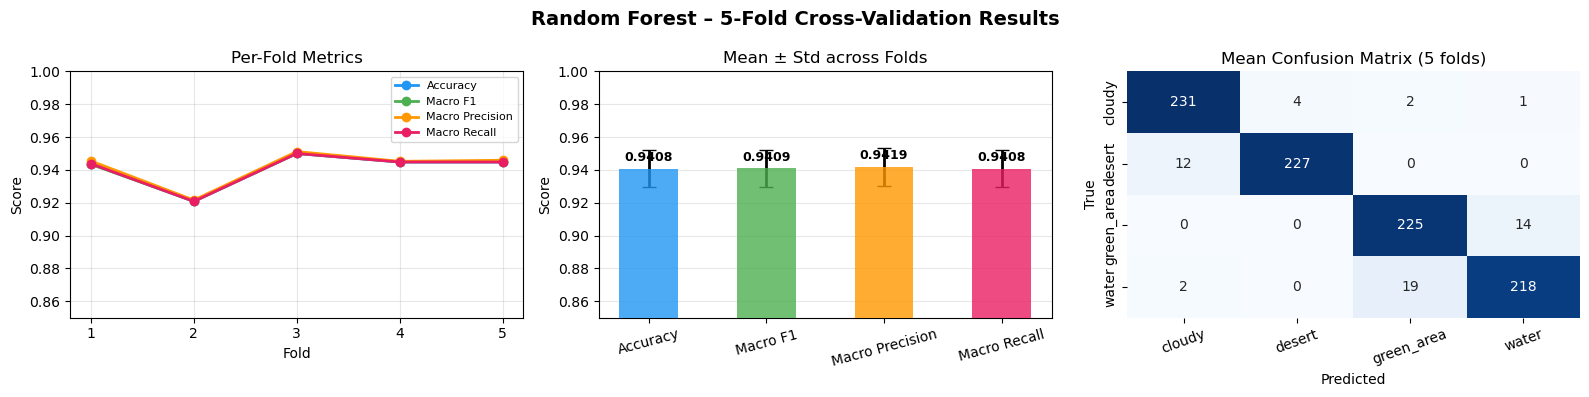

Saved → results/rf_cv_results.png


In [6]:
## ── CV Visualisation ─────────────────────────────────────────────────────────
fig, axes = plt.subplots(1, 3, figsize=(16, 4))
fig.suptitle("Random Forest – 5-Fold Cross-Validation Results", fontsize=14, fontweight='bold')

# 1. Per-fold metrics line chart
metrics_to_plot = ["Accuracy", "Macro F1", "Macro Precision", "Macro Recall"]
colors = ['#2196F3', '#4CAF50', '#FF9800', '#E91E63']
ax = axes[0]
for m, c in zip(metrics_to_plot, colors):
    ax.plot(cv_df["Fold"], cv_df[m], marker='o', label=m, color=c, linewidth=2)
ax.set_xlabel("Fold")
ax.set_ylabel("Score")
ax.set_title("Per-Fold Metrics")
ax.set_xticks(cv_df["Fold"])
ax.set_ylim(0.85, 1.0)
ax.legend(fontsize=8)
ax.grid(True, alpha=0.3)

# 2. Box-style bar chart of mean ± std
ax2 = axes[1]
mean_vals = [means[m] for m in metrics_to_plot]
std_vals  = [stds[m]  for m in metrics_to_plot]
bars = ax2.bar(metrics_to_plot, mean_vals, color=colors, alpha=0.8, width=0.5, zorder=3)
ax2.errorbar(metrics_to_plot, mean_vals, yerr=std_vals, fmt='none',
             color='black', capsize=5, linewidth=2)
ax2.set_ylim(0.85, 1.0)
ax2.set_ylabel("Score")
ax2.set_title("Mean ± Std across Folds")
ax2.grid(True, alpha=0.3, axis='y', zorder=0)
for bar, val in zip(bars, mean_vals):
    ax2.text(bar.get_x() + bar.get_width()/2, val + 0.003,
             f"{val:.4f}", ha='center', va='bottom', fontsize=9, fontweight='bold')
ax2.tick_params(axis='x', rotation=15)

# 3. Mean confusion matrix across folds
mean_cm = np.mean(fold_cms, axis=0).astype(int)
ax3 = axes[2]
sns.heatmap(mean_cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=CLASSES, yticklabels=CLASSES, ax=ax3, cbar=False)
ax3.set_title("Mean Confusion Matrix (5 folds)")
ax3.set_xlabel("Predicted")
ax3.set_ylabel("True")
ax3.tick_params(axis='x', rotation=20)

plt.tight_layout()
plt.savefig(RESULTS_DIR / "rf_cv_results.png",
            dpi=150, bbox_inches='tight')
plt.show()
print("Saved → results/rf_cv_results.png")

In [7]:
## ── Retrain on full training set ─────────────────────────────────────────────
print("Training Random Forest on the full training set (n_estimators=100, default params)...")
t0 = time.time()
rf_final = RandomForestClassifier(**RF_PARAMS)
rf_final.fit(X_train_flat, y_train)
train_elapsed = time.time() - t0
print(f"Done in {train_elapsed:.2f}s  |  {X_train_flat.shape[0]} samples  |  {X_train_flat.shape[1]} features")

Training Random Forest on the full training set (n_estimators=100, default params)...
Done in 1.20s  |  4800 samples  |  12288 features


RANDOM FOREST – TEST SET RESULTS
  Accuracy          : 0.9383
  Macro Precision   : 0.9390
  Macro Recall      : 0.9383
  Macro F1          : 0.9384

Detailed Classification Report:
              precision    recall  f1-score   support

      cloudy     0.9270    0.9733    0.9496       300
      desert     0.9825    0.9333    0.9573       300
  green_area     0.9298    0.9267    0.9282       300
       water     0.9169    0.9200    0.9185       300

    accuracy                         0.9383      1200
   macro avg     0.9390    0.9383    0.9384      1200
weighted avg     0.9390    0.9383    0.9384      1200



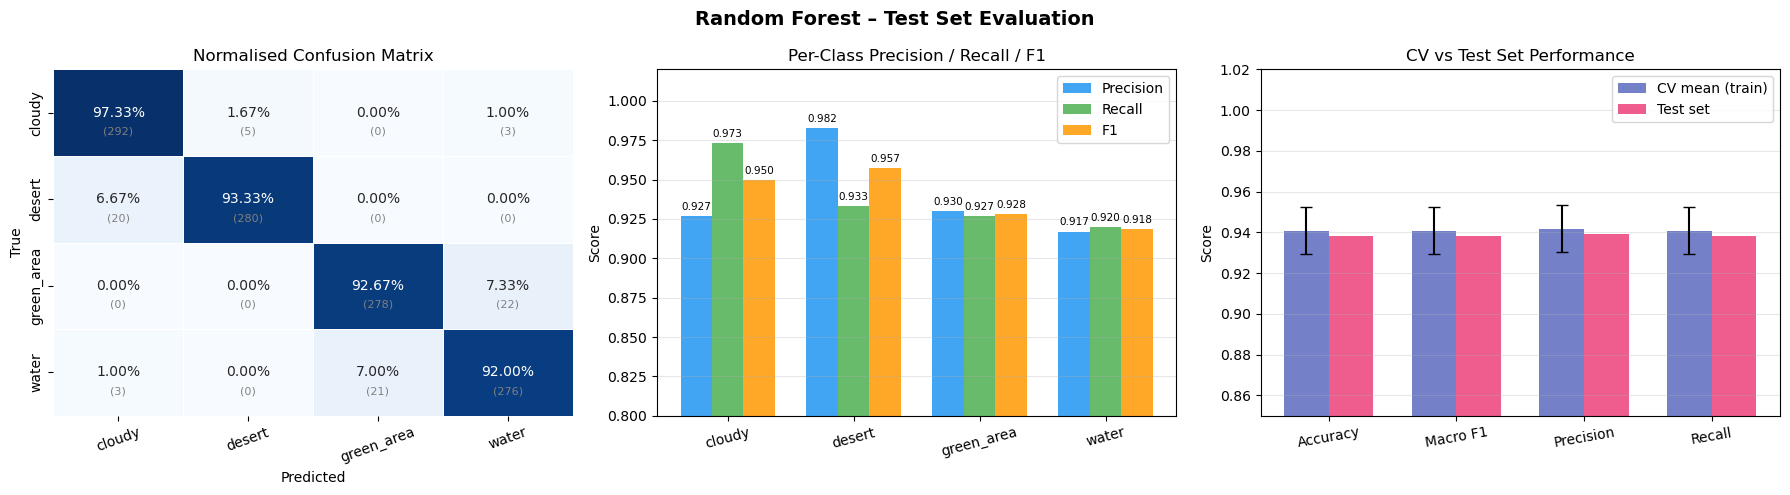

Saved → results/rf_test_evaluation.png

FINAL SUMMARY – Random Forest (n_estimators=100, defaults)
  5-Fold CV Accuracy : 0.9408 ± 0.0114
  5-Fold CV F1       : 0.9409 ± 0.0114
  Test Accuracy      : 0.9383
  Test Macro F1      : 0.9384

Per-Class Performance on Test Set:
     Class  Precision   Recall       F1  Support
    cloudy   0.926984 0.973333 0.949593      300
    desert   0.982456 0.933333 0.957265      300
green_area   0.929766 0.926667 0.928214      300
     water   0.916944 0.920000 0.918469      300


In [9]:
## ── Test-Set Evaluation ───────────────────────────────────────────────────────
y_test_pred = rf_final.predict(X_test_flat)
y_test_prob = rf_final.predict_proba(X_test_flat)

test_acc  = accuracy_score(y_test, y_test_pred)
test_f1   = f1_score(y_test, y_test_pred, average='macro')
test_prec = precision_score(y_test, y_test_pred, average='macro', zero_division=0)
test_rec  = recall_score(y_test, y_test_pred, average='macro', zero_division=0)
test_cm   = confusion_matrix(y_test, y_test_pred)

print("="*60)
print("RANDOM FOREST – TEST SET RESULTS")
print("="*60)
print(f"  Accuracy          : {test_acc:.4f}")
print(f"  Macro Precision   : {test_prec:.4f}")
print(f"  Macro Recall      : {test_rec:.4f}")
print(f"  Macro F1          : {test_f1:.4f}")
print("="*60)

print("\nDetailed Classification Report:")
print(classification_report(y_test, y_test_pred, target_names=CLASSES, digits=4))

# ── Visualisation ─────────────────────────────────────────────────────────────
fig, axes = plt.subplots(1, 3, figsize=(18, 5))
fig.suptitle("Random Forest – Test Set Evaluation", fontsize=14, fontweight='bold')

# 1. Confusion matrix
ax = axes[0]
cm_norm = test_cm.astype(float) / test_cm.sum(axis=1, keepdims=True)
sns.heatmap(cm_norm, annot=True, fmt='.2%', cmap='Blues',
            xticklabels=CLASSES, yticklabels=CLASSES, ax=ax, cbar=False,
            linewidths=0.5, linecolor='white')
# Overlay raw counts
for i in range(len(CLASSES)):
    for j in range(len(CLASSES)):
        ax.text(j + 0.5, i + 0.72, f"({test_cm[i,j]})",
                ha='center', va='center', fontsize=8, color='gray')
ax.set_title("Normalised Confusion Matrix")
ax.set_xlabel("Predicted")
ax.set_ylabel("True")
ax.tick_params(axis='x', rotation=20)

# 2. Per-class metrics bar chart
per_class_prec = precision_score(y_test, y_test_pred, average=None, zero_division=0)
per_class_rec  = recall_score(y_test, y_test_pred, average=None, zero_division=0)
per_class_f1   = f1_score(y_test, y_test_pred, average=None, zero_division=0)

x = np.arange(len(CLASSES))
width = 0.25
ax2 = axes[1]
ax2.bar(x - width, per_class_prec, width, label='Precision', color='#2196F3', alpha=0.85)
ax2.bar(x,         per_class_rec,  width, label='Recall',    color='#4CAF50', alpha=0.85)
ax2.bar(x + width, per_class_f1,   width, label='F1',        color='#FF9800', alpha=0.85)
ax2.set_xticks(x)
ax2.set_xticklabels(CLASSES, rotation=15)
ax2.set_ylim(0.8, 1.02)
ax2.set_ylabel("Score")
ax2.set_title("Per-Class Precision / Recall / F1")
ax2.legend()
ax2.grid(True, alpha=0.3, axis='y')
for i, (p, r, f) in enumerate(zip(per_class_prec, per_class_rec, per_class_f1)):
    ax2.text(i - width, p + 0.004, f"{p:.3f}", ha='center', fontsize=7.5)
    ax2.text(i,         r + 0.004, f"{r:.3f}", ha='center', fontsize=7.5)
    ax2.text(i + width, f + 0.004, f"{f:.3f}", ha='center', fontsize=7.5)

# 3. CV vs Test comparison
ax3 = axes[2]
summary_metrics = ["Accuracy", "Macro F1", "Macro Precision", "Macro Recall"]
cv_means  = [means[m] for m in summary_metrics]
test_vals = [test_acc, test_f1, test_prec, test_rec]
x3 = np.arange(len(summary_metrics))
w  = 0.35
ax3.bar(x3 - w/2, cv_means,  w, label='CV mean (train)', color='#5C6BC0', alpha=0.85)
ax3.bar(x3 + w/2, test_vals, w, label='Test set',        color='#EC407A', alpha=0.85)
ax3.errorbar(x3 - w/2, cv_means, yerr=[stds[m] for m in summary_metrics],
             fmt='none', color='black', capsize=4, linewidth=1.5)
ax3.set_xticks(x3)
ax3.set_xticklabels(["Accuracy", "Macro F1", "Precision", "Recall"], rotation=10)
ax3.set_ylim(0.85, 1.02)
ax3.set_ylabel("Score")
ax3.set_title("CV vs Test Set Performance")
ax3.legend()
ax3.grid(True, alpha=0.3, axis='y')

plt.tight_layout()
plt.savefig(RESULTS_DIR / "rf_test_evaluation.png",
            dpi=150, bbox_inches='tight')
plt.show()
print("Saved → results/rf_test_evaluation.png")

# ── Final summary ─────────────────────────────────────────────────────────────
print("\n" + "="*60)
print("FINAL SUMMARY – Random Forest (n_estimators=100, defaults)")
print("="*60)
print(f"  5-Fold CV Accuracy : {means['Accuracy']:.4f} ± {stds['Accuracy']:.4f}")
print(f"  5-Fold CV F1       : {means['Macro F1']:.4f} ± {stds['Macro F1']:.4f}")
print(f"  Test Accuracy      : {test_acc:.4f}")
print(f"  Test Macro F1      : {test_f1:.4f}")
print("="*60)

per_class_report = pd.DataFrame({
    'Class'    : CLASSES,
    'Precision': per_class_prec,
    'Recall'   : per_class_rec,
    'F1'       : per_class_f1,
    'Support'  : test_cm.sum(axis=1)
})
print("\nPer-Class Performance on Test Set:")
print(per_class_report.to_string(index=False))